## 1.0 Парсинг файла с данными по ежемесячным ценам угля.

In [18]:
import pandas as pd
file_path = 'CMO-Historical-Data-Monthly.xlsx'
df_prices = pd.read_excel(file_path, sheet_name='Monthly Prices', header=5)
# По заголовкам из файла: Australian Coal в колонке F, South African Coal в колонке G
df_coal = df_prices.iloc[:, [0, 5, 6]].copy()  # A, F, G
df_coal.columns = ['Date', 'Australian_Coal', 'South_African_Coal']
df_coal['Date'] = pd.to_datetime(df_coal['Date'], format='%YM%m')
df_coal = df_coal.dropna()

for col in ['Australian_Coal', 'South_African_Coal']:
    df_coal[col] = pd.to_numeric(df_coal[col], errors='coerce')
df_coal = df_coal.dropna()
df_coal.reset_index(drop=True, inplace=True)
print(df_coal.head(10))
print(f"\nДиапазон данных: {df_coal['Date'].min()} — {df_coal['Date'].max()}")
print(f"Всего строк: {len(df_coal)}")


        Date  Australian_Coal  South_African_Coal
0 1984-01-01            29.25               29.34
1 1984-02-01            29.25               29.34
2 1984-03-01            29.25               29.34
3 1984-04-01            29.25               29.34
4 1984-05-01            29.25               29.34
5 1984-06-01            31.75               34.31
6 1984-07-01            31.75               35.80
7 1984-08-01            31.75               35.80
8 1984-09-01            31.75               35.80
9 1984-10-01            31.75               35.80

Диапазон данных: 1984-01-01 00:00:00 — 2026-05-01 00:00:00
Всего строк: 509


## 1.1 Парсинг файла с данными по погрузке угля (Росстат)

In [14]:
file_path = "Pogruzka-04-2026.xlsx"  
years = list(range(2005, 2027))
data = []

for year in years:
    try:
        df = pd.read_excel(file_path, sheet_name=str(year), header=None)
    except Exception as e:
        print(f"Лист {year} не найден: {e}")
        continue
    
    # Ищем строку с "каменный уголь"
    mask = df[0].astype(str).str.contains("каменный уголь", na=False)
    if not mask.any():
        print(f"В листе {year} не найдена строка с 'каменный уголь'")
        continue
    
    row_idx = mask[mask].index[0]
    # Месяцы со столбца B (индекс 1) по M (индекс 12)
    monthly_values = df.iloc[row_idx, 1:13].values
    
    # Записываем каждый месяц
    for month_num, value in enumerate(monthly_values, start=1):
        if pd.notna(value):
            date = pd.Timestamp(year=year, month=month_num, day=1)
            data.append({"date": date, "coal_loading": value})


df_gruz = pd.DataFrame(data)
df_gruz = df_gruz.sort_values("date").reset_index(drop=True)

print(df_gruz.head(20))
print(f"\nВсего записей: {len(df_gruz)}")
print(f"\nПериод: с {df_gruz['date'].min()} по {df_gruz['date'].max()}")


         date  coal_loading
0  2005-01-01       25391.0
1  2005-02-01       22853.0
2  2005-03-01       24552.0
3  2005-04-01       21681.0
4  2005-05-01       21661.0
5  2005-06-01       20481.0
6  2005-07-01       20024.0
7  2005-08-01       21981.0
8  2005-09-01       22948.0
9  2005-10-01       25410.0
10 2005-11-01       25980.0
11 2005-12-01       25286.0
12 2006-01-01       24102.0
13 2006-02-01       23507.0
14 2006-03-01       25817.0
15 2006-04-01       23601.0
16 2006-05-01       22918.0
17 2006-06-01       21753.0
18 2006-07-01       21818.0
19 2006-08-01       22823.0

Всего записей: 256

Период: с 2005-01-01 00:00:00 по 2026-04-01 00:00:00


## 1.3 Парсинг данных по курсу рубля к доллару, изначально подневные - берем среднее за месяц.

In [15]:
# Загрузка данных из файла
file_path = "RC_F01_01_2005_T06_06_2026.xlsx"
df = pd.read_excel(file_path, sheet_name="RC")
df.columns = ["nominal", "data", "curs", "cdx"]
df["data"] = pd.to_datetime(df["data"])
df["ano_mes"] = df["data"].dt.to_period("M")

media_mensal = df.groupby("ano_mes")["curs"].mean().reset_index()
media_mensal["date"] = media_mensal["ano_mes"].dt.start_time
df_kurs = media_mensal[["date", "curs"]].copy()
df_kurs.rename(columns={"curs": "kurs"}, inplace=True)
print(df_kurs)

          date       kurs
0   2005-01-01  28.009087
1   2005-02-01  27.995395
2   2005-03-01  27.626423
3   2005-04-01  27.810355
4   2005-05-01  27.951378
..         ...        ...
253 2026-02-01  76.927800
254 2026-03-01  80.503740
255 2026-04-01  76.889773
256 2026-05-01  72.811205
257 2026-06-01  73.044200

[258 rows x 2 columns]


## 1.4 Обьединение данных

In [21]:
df_coal = df_coal.rename(columns={'Date': 'date'})
df_gruz = df_gruz.rename(columns={'date': 'date'})  # уже 'date'
df_kurs = df_kurs.rename(columns={'date': 'date'})  # уже 'date'
df_coal['date'] = pd.to_datetime(df_coal['date'])
df_gruz['date'] = pd.to_datetime(df_gruz['date'])
df_kurs['date'] = pd.to_datetime(df_kurs['date'])
df_merged = pd.merge(df_coal, df_gruz, on='date', how='inner')
df_merged = pd.merge(df_merged, df_kurs, on='date', how='inner')
df_merged = df_merged.sort_values('date').reset_index(drop=True)
final_columns = ['date']
for col in ['Australian_Coal', 'South_African_Coal', 'coal_loading', 'kurs']:
    if col in df_merged.columns:
        final_columns.append(col)
df_merged = df_merged[final_columns]
print(f"\nИтоговый датасет без пропусков:")
print(df_merged.head(10))

df_merged.to_csv("coal_forecast_1.csv", index=False, encoding="utf-8")


Итоговый датасет без пропусков:
        date  Australian_Coal  South_African_Coal  coal_loading       kurs
0 2005-01-01            53.05               51.42       25391.0  28.009087
1 2005-02-01            49.90               46.63       22853.0  27.995395
2 2005-03-01            50.93               45.30       24552.0  27.626423
3 2005-04-01            51.25               46.25       21681.0  27.810355
4 2005-05-01            51.31               45.88       21661.0  27.951378
5 2005-06-01            51.00               49.13       20481.0  28.497867
6 2005-07-01            50.90               51.31       20024.0  28.694432
7 2005-08-01            49.13               49.50       21981.0  28.479809
8 2005-09-01            45.25               46.63       22948.0  28.380014
9 2005-10-01            42.46               43.25       25410.0  28.563133


## 2.1 Визуализация переменных

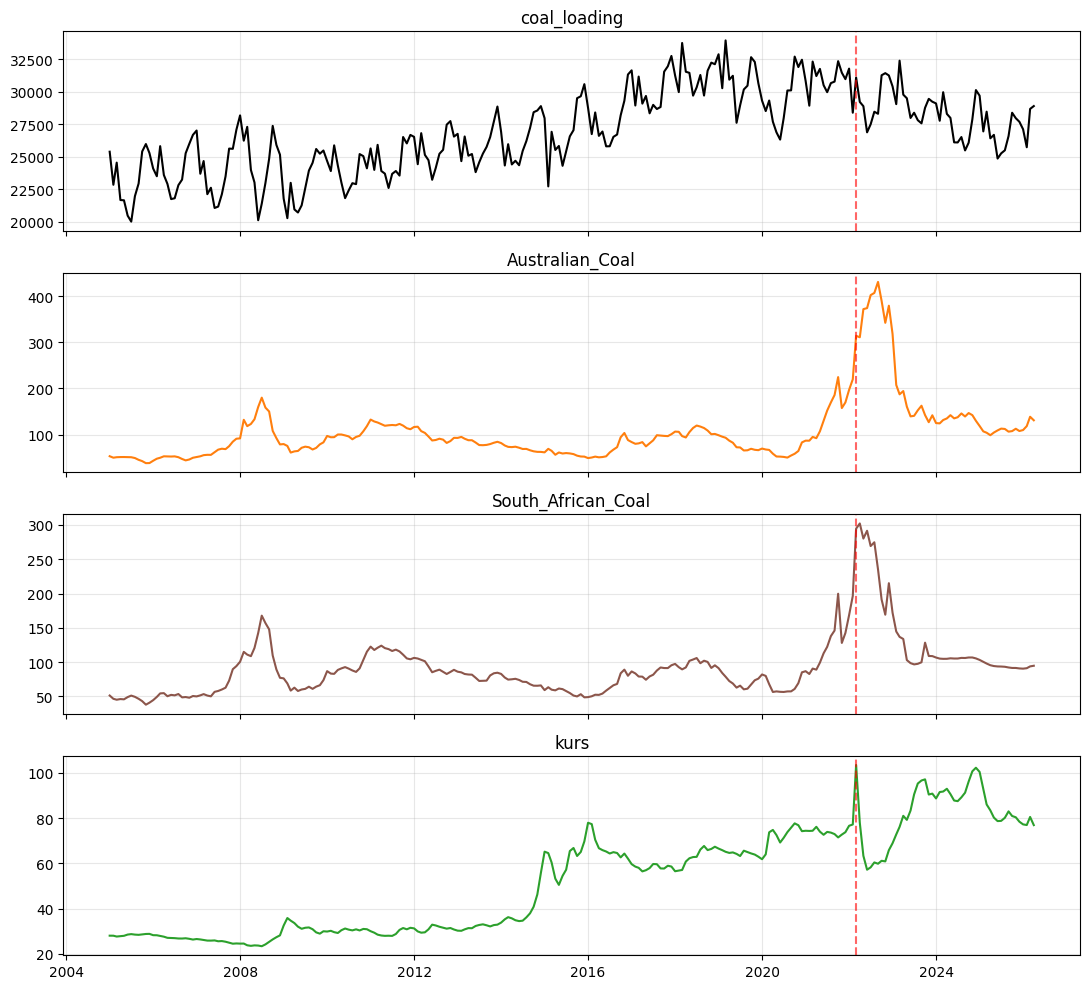

In [35]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
df = pd.read_csv("coal_forecast_1.csv", parse_dates=["date"]).set_index("date")

cols   = ["coal_loading", "Australian_Coal", "South_African_Coal", "kurs"]
colors = ["black", "tab:orange", "tab:brown", "tab:green"]

fig, ax = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
for a, c, col in zip(ax, cols, colors):
    a.plot(df.index, df[c], color=col); a.set_title(c); a.grid(alpha=.3)
    a.axvline(pd.Timestamp("2022-03-01"), color="red", ls="--", alpha=.6)
plt.tight_layout();plt.show()

## 2.2 Корреляционная матрица

                    Australian_Coal  South_African_Coal  coal_loading  kurs
Australian_Coal                1.00                0.94          0.28  0.30
South_African_Coal             0.94                1.00          0.27  0.26
coal_loading                   0.28                0.27          1.00  0.66
kurs                           0.30                0.26          0.66  1.00
                    Australian_Coal  South_African_Coal  coal_loading  kurs
Australian_Coal                1.00                0.97          0.32  0.34
South_African_Coal             0.97                1.00          0.32  0.28
coal_loading                   0.32                0.32          1.00  0.70
kurs                           0.34                0.28          0.70  1.00


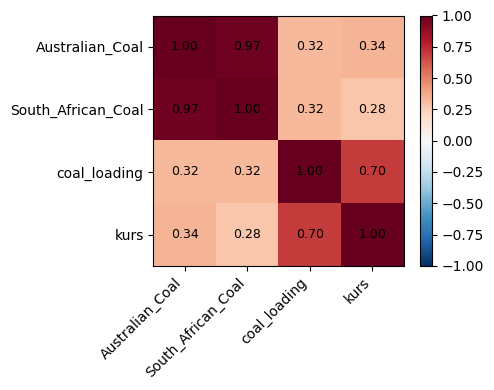

In [36]:
print(df.corr().round(2))
print(np.log(df).corr().round(2))

c = np.log(df).corr()
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(c, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(c))); ax.set_xticklabels(c.columns, rotation=45, ha="right")
ax.set_yticks(range(len(c))); ax.set_yticklabels(c.columns)
for i in range(len(c)):
    for j in range(len(c)):
        ax.text(j, i, f"{c.iloc[i,j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im); plt.tight_layout(); plt.show()

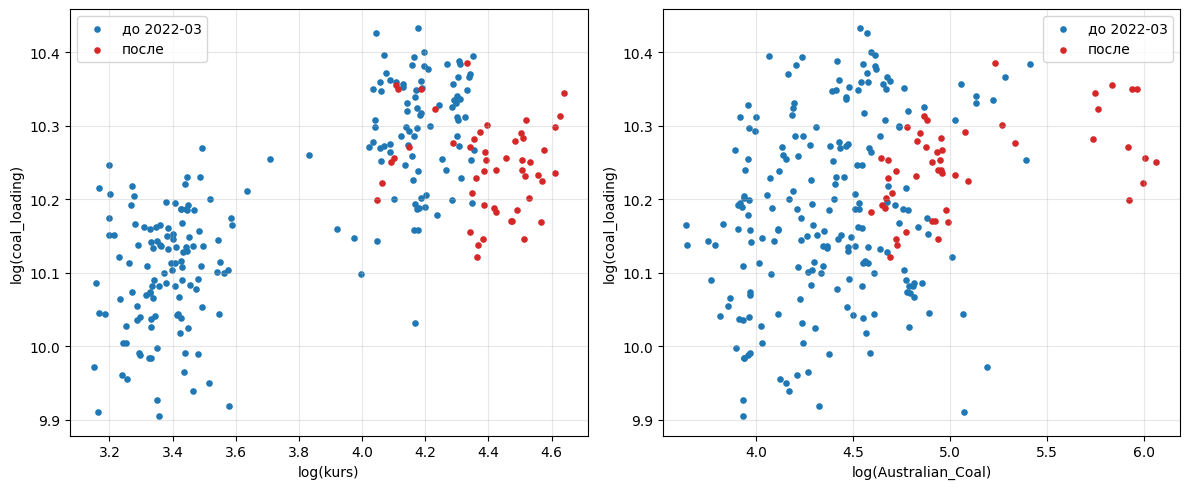

In [37]:
ld  = np.log(df)
pre = df.index < "2022-03-01"

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, x in zip(ax, ["kurs", "Australian_Coal"]):
    a.scatter(ld[x][pre],  ld["coal_loading"][pre],  s=14, c="tab:blue", label="до 2022-03")
    a.scatter(ld[x][~pre], ld["coal_loading"][~pre], s=14, c="tab:red",  label="после")
    a.set_xlabel(f"log({x})"); a.set_ylabel("log(coal_loading)"); a.grid(alpha=.3); a.legend()
plt.tight_layout(); plt.show()

## 3.1 Оценка простой регрессии МНК с сезональностью

In [39]:
import statsmodels.formula.api as smf
test_n = 24
train, test = d.iloc[:-test_n], d.iloc[-test_n:]

m = smf.ols("lcoal ~ lprice + lfx + C(month)", data=train).fit()

pred = np.exp(m.predict(test))       
actual = np.exp(test["lcoal"])
resid  = actual - pred

mape = (resid.abs() / actual).mean() * 100
bias = (resid / actual).mean() * 100    # знак систематической ошибки

print(f"MAPE = {mape:.1f}%")
print(f"Bias = {bias:+.1f}%   ({'переоценивает' if bias < 0 else 'недооценивает'} факт)")

MAPE = 13.5%
Bias = -13.5%   (переоценивает факт)


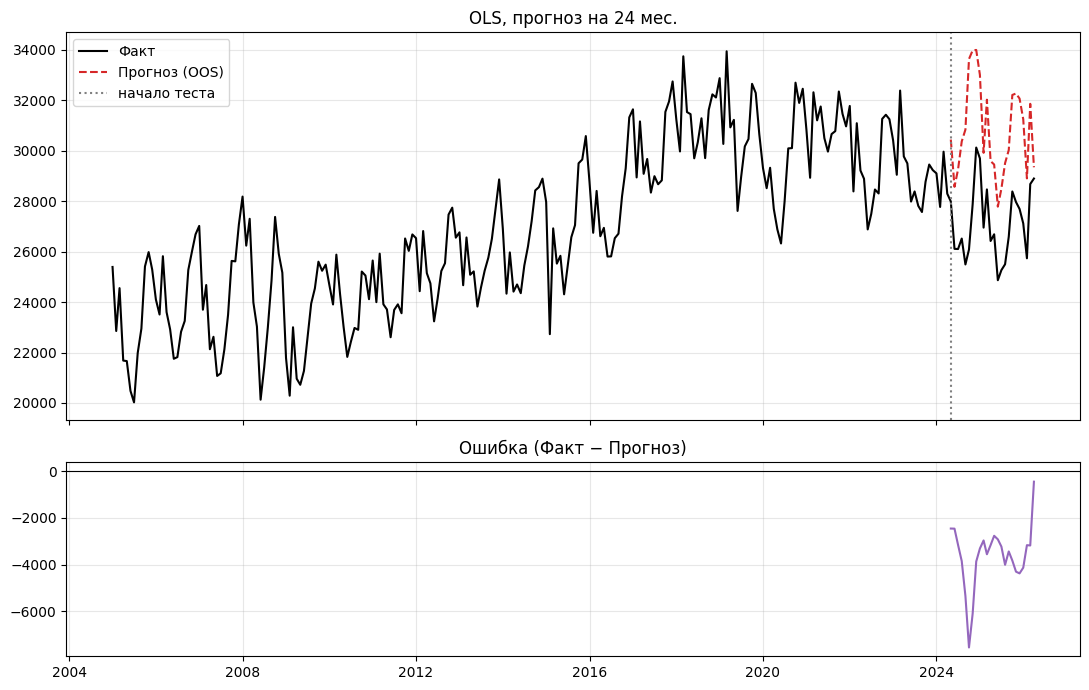

In [46]:
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                       gridspec_kw={"height_ratios": [2, 1]})
ax[0].plot(np.exp(d["lcoal"]), color="black", label="Факт")
ax[0].plot(pred, color="tab:red", ls="--", label="Прогноз (OOS)")
ax[0].axvline(test.index[0], color="gray", ls=":", label="начало теста")
ax[0].legend(); ax[0].grid(alpha=.3); ax[0].set_title(f"OLS, прогноз на {test_n} мес.")
ax[1].plot(resid.index, resid, color="tab:purple"); ax[1].axhline(0, color="k", lw=.8)
ax[1].set_title("Ошибка (Факт − Прогноз)"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

In [51]:
start = len(d) - 24
rows = []
for i in range(start, len(d)):
    m = smf.ols("lcoal ~ lprice + lfx + C(month)", data=d.iloc[:i]).fit()
    p = float(np.exp(m.predict(d.iloc[[i]]).iloc[0]))
    rows.append((d.index[i], np.exp(d["lcoal"].iloc[i]), p))

roll = pd.DataFrame(rows, columns=["date", "actual", "pred"]).set_index("date")
roll["err"] = roll.actual - roll.pred
print(f'Rolling MAPE = {(roll.err.abs()/roll.actual).mean()*100:.1f}%')
print(f'Rolling Bias = {(roll.err/roll.actual).mean()*100:+.1f}%')

Rolling MAPE = 11.9%
Rolling Bias = -11.8%


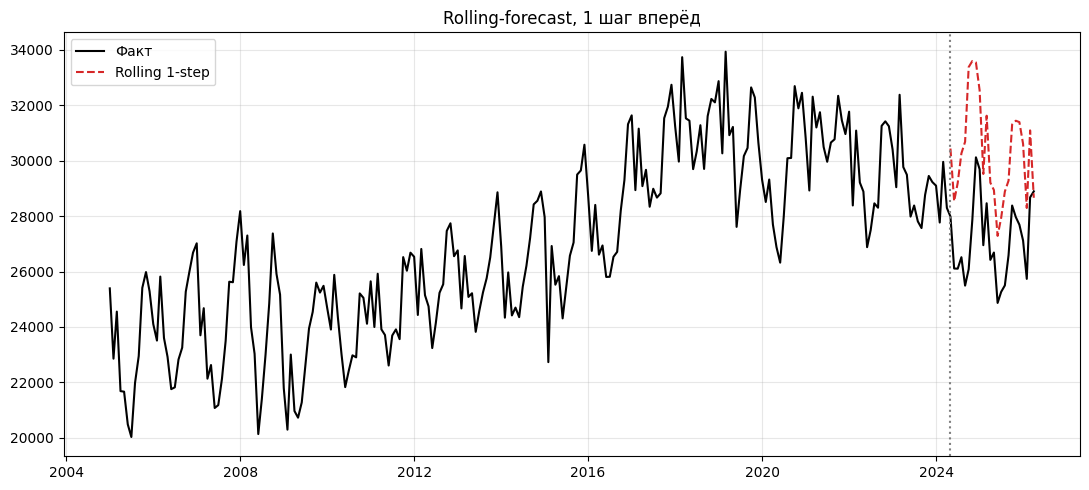

In [52]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(np.exp(d["lcoal"]), color="black", label="Факт")
ax.plot(roll.pred, color="tab:red", ls="--", label="Rolling 1-step")
ax.axvline(roll.index[0], color="gray", ls=":")
ax.legend(); ax.grid(alpha=.3); ax.set_title("Rolling-forecast, 1 шаг вперёд")
plt.tight_layout(); plt.show()

## 3.2 DW TEST сильно меньше 1, есть автокорреляция, добавляем 1 лаг целевой переменной

In [58]:
d["lcoal_lag1"] = d["lcoal"].shift(1)          # один раз, до цикла

start = len(d) - 24
rows = []
for i in range(start, len(d)):
    train = d.iloc[:i].dropna()                # dropna из-за лага в первой строке
    m = smf.ols("lcoal ~ lcoal_lag1 + lprice + lfx + C(month)", data=train).fit()
    p = float(np.exp(m.predict(d.iloc[[i]]).iloc[0]))
    rows.append((d.index[i], np.exp(d["lcoal"].iloc[i]), p))

roll = pd.DataFrame(rows, columns=["date", "actual", "pred"]).set_index("date")
roll["err"] = roll.actual - roll.pred
print(f'MAPE = {(roll.err.abs()/roll.actual).mean()*100:.1f}%')
print(f'Bias = {(roll.err/roll.actual).mean()*100:+.1f}%')

MAPE = 3.0%
Bias = -1.0%


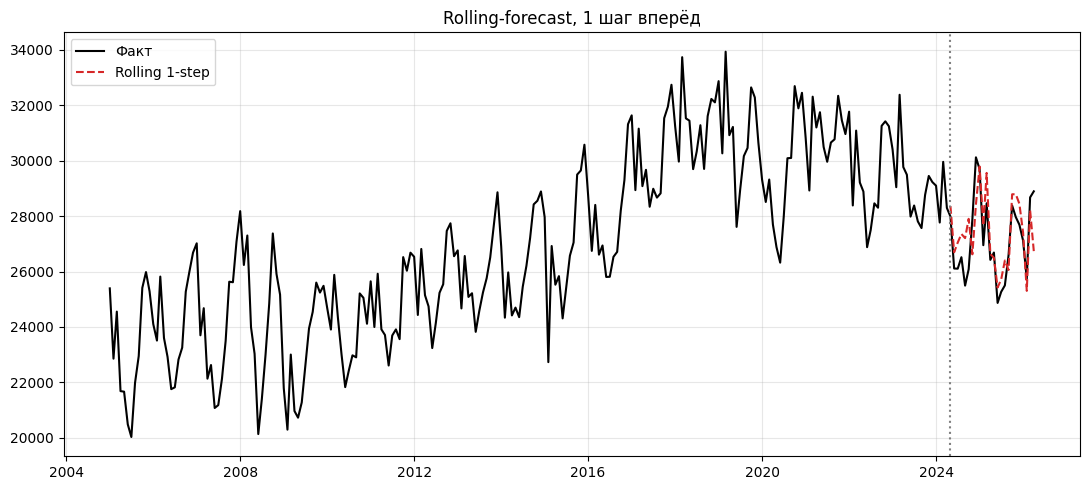

In [59]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(np.exp(d["lcoal"]), color="black", label="Факт")
ax.plot(roll.pred, color="tab:red", ls="--", label="Rolling 1-step")
ax.axvline(roll.index[0], color="gray", ls=":")
ax.legend(); ax.grid(alpha=.3); ax.set_title("Rolling-forecast, 1 шаг вперёд")
plt.tight_layout(); plt.show()

In [60]:
m.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lcoal   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     246.4
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          3.03e-133
Time:                        16:30:51   Log-Likelihood:                 530.25
No. Observations:                 254   AIC:                            -1030.
Df Residuals:                     239   BIC:                            -977.4
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.8599      0.275      3.131      0.002       0.319       1.401
C(month)[T.2]     -0.0594      0.009     -6.285      0.000      -0.078      -0.041
C(month)[T.3]      0.0961      0.010      9.749      0.000       0.077       0.116
C(month)[T.4]     -0.0564      0.010     -5.901      0.000      -0.075      -0.038
C(month)[T.5]      0.0076      0.010      0.774      0.440      -0.012       0.027
C(month)[T.6]     -0.0439      0.010     -4.452      0.000      -0.063      -0.024
C(month)[T.7]      0.0320      0.010      3.073      0.002       0.011       0.052
C(month)[T.8]      0.0429      0.010      4.221      0.000       0.023       0.063
C(month)[T.9]      0.0241      0.010      2.436      0.016       0.005       0.044
C(month)[T.10]     0.0842      0.010      8.596      0.000       0.065       0.104
C(month)[T.11]     0.0245      0.010      2.567      0.011       0.006       0.043
C(month)[T.12]     0.0268      0.010      2.813      0.005       0.008       0.046
lcoal_lag1         0.9087      0.029     31.502      0.000       0.852       0.966
lprice          3.768e-05      0.004      0.008      0.993      -0.009       0.009
lfx                0.0145      0.007      2.197      0.029       0.002       0.028
==============================================================================
Omnibus:                       30.608   Durbin-Watson:                   1.794
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.951
Skew:                          -0.630   Prob(JB):                     9.59e-14
Kurtosis:                       5.019   Cond. No.                     1.69e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.69e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 3.3 Коэффициент при лаге примерно 1, что нехорошо, так как в реальности данные появляются с запаздыванием и планирование долгосрочное

In [63]:
train = d[d.index < "2024-01-01"].dropna()
test  = d[d.index >= "2024-01-01"]
m = smf.ols("lcoal ~ lcoal_lag1 + lprice + lfx + C(month)", data=train).fit()

last_lag = train["lcoal"].iloc[-1]      # последний реальный факт
preds = []
for dt, row in test.iterrows():
    x = row.copy()
    x["lcoal_lag1"] = last_lag          # подставляем прошлый прогноз (на 1-м шаге — факт)
    yhat = m.predict(pd.DataFrame([x])).iloc[0]
    preds.append(yhat)
    last_lag = yhat                     # ключевая строка: прогноз становится лагом

roll = pd.DataFrame({"actual": np.exp(test["lcoal"]),
                     "pred":   np.exp(preds)}, index=test.index)
roll["err"] = roll.actual - roll.pred
print(f'MAPE = {(roll.err.abs()/roll.actual).mean()*100:.1f}%')
print(f'Bias = {(roll.err/roll.actual).mean()*100:+.1f}%')

MAPE = 9.8%
Bias = -9.5%


## 3.4 Присутствует структурный сдвиг после 2022, также прогноз делаем на квартал, поэтому меняем rolling backtest, т.е. модель будет видеть каждые 3 месяца реальные данные.   

d["post2022"] = (d.index >= "2022-03-01").astype(int)

def backtest(formula, frozen=False, H=3, test_n=24):
    rows = []
    for i in range(len(d)-test_n, len(d)-H+1):
        m = smf.ols(formula, data=d.iloc[:i].dropna()).fit()
        hist = d["lcoal"].values.copy()
        fx0, price0 = d["lfx"].iloc[i-1], d["lprice"].iloc[i-1]   # заморозка на origin-1
        for h in range(H):
            j = i + h; x = d.iloc[j].copy()
            if frozen: x["lfx"] = fx0; x["lprice"] = price0       # вместо реального будущего
            x["lcoal_lag1"] = hist[j-1]
            yh = float(m.predict(pd.DataFrame([x])).iloc[0])
            rows.append((d.index[j], h+1, np.exp(d["lcoal"].iloc[j]), np.exp(yh))); hist[j] = yh
    r = pd.DataFrame(rows, columns=["date","h","actual","pred"]); r["err"] = r.actual-r.pred
    return r


f = "lcoal ~ lcoal_lag1 + lprice + lfx + C(month) + post2022"
r = backtest(f)
print(f'квартал: MAPE={(r.err.abs()/r.actual).mean()*100:.1f}%  Bias={(r.err/r.actual).mean()*100:+.1f}%')
for h in (1,2,3):
    s = r[r.h==h]; print(f'  h={h}: MAPE={(s.err.abs()/s.actual).mean()*100:.1f}%  Bias={(s.err/s.actual).mean()*100:+.1f}%')

Дальнейшие дешевые улчушения a la AR(2) и лаги других переменных MAPE не двигают, поэтому нужны другие данные.

## 3.5 Курс и цены в оценке изначальной модели предполагался известным, однако в реальности это не так, поэтому в реальности при оценке будет накапливаться еще и ошибка предсказания курса и цены. В данной секции проверим будут ли сильные изменения, если мы заморозим курс и цену, сильно ли измениться MAPE

In [81]:
print(f"MAPE with frozen prices and exchange rate :{backtest(f, frozen=True).pipe(lambda r: (r.err.abs()/r.actual).mean()*100)}")

MAPE with frozen prices and exchange rate :3.7189352407689085


Таким образом, разница в MAPE даже с фиксированным курсом и ценами угля незначительная. 

## 3.6 Ряд получается похожим на случайное блуждание, т.к. очень высокие коэффициент у лага. Значит осталось проверить на единичный корень.

In [82]:
from statsmodels.tsa.stattools import adfuller
print(adfuller(d["lcoal"].dropna())[1])   # p-value

0.4521223314437343


ADF не отвергает единичный корень...

## 3.7 Проверим стационарность в первых разностях и проведем тесты на коинтеграцию

In [85]:
"""
Уголь: разностная модель (квартальный бэктест) + тесты на коинтеграцию.
Соответствует последнему разбору: проверяем, законна ли level-модель,
и есть ли долгосрочная связь погрузки с курсом/ценой (и не сломал ли её 2022-й).
"""

import pandas as pd, numpy as np
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# --- данные ---
df = pd.read_csv("coal_forecast_1.csv", parse_dates=["date"]).set_index("date")
d = np.log(df[["coal_loading", "Australian_Coal", "kurs"]]).rename(
    columns={"coal_loading": "lcoal", "Australian_Coal": "lprice", "kurs": "lfx"})
d["month"] = d.index.month
d["dcoal"]  = d["lcoal"].diff()
d["dfx"]    = d["lfx"].diff()
d["dprice"] = d["lprice"].diff()
d["dcoal_lag1"] = d["dcoal"].shift(1)


# --- рекурсивный квартальный бэктест в РАЗНОСТЯХ ---
# прогнозируем прирост, кумулятивно собираем уровень; frozen=True -> X замораживаем (dX=0)
def backtest_diff(formula, tgt_lags, frozen=False, H=3, test_n=24):
    rows = []
    for i in range(len(d) - test_n, len(d) - H + 1):
        m = smf.ols(formula, data=d.iloc[:i].dropna()).fit()
        dh = d["dcoal"].values.copy()          # история приростов
        level = d["lcoal"].iloc[i - 1]         # реальный последний уровень
        for h in range(H):
            j = i + h
            x = d.iloc[j].copy()
            if frozen:
                x["dfx"] = 0.0; x["dprice"] = 0.0
            for k in tgt_lags:
                x[f"dcoal_lag{k}"] = dh[j - k]
            dyh = float(m.predict(pd.DataFrame([x])).iloc[0])
            level = level + dyh                 # собираем уровень из приростов
            rows.append((d.index[j], h + 1, np.exp(d["lcoal"].iloc[j]), np.exp(level)))
            dh[j] = dyh
    r = pd.DataFrame(rows, columns=["date", "h", "actual", "pred"])
    r["err"] = r.actual - r.pred
    return r


f = "dcoal ~ dcoal_lag1 + dfx + dprice + C(month)"
for label, fr in [("РАЗНОСТИ, реальные X", False), ("РАЗНОСТИ, заморозка X", True)]:
    r = backtest_diff(f, [1], frozen=fr)
    mape = (r.err.abs() / r.actual).mean() * 100
    bias = (r.err / r.actual).mean() * 100
    print(f"{label}: MAPE={mape:.1f}%  Bias={bias:+.1f}%")
print("  (LEVEL-модель давала: MAPE 3.6% / Bias -1.3% при реальных X)\n")

# коэффициенты разностной модели на всей выборке
mm = smf.ols(f, data=d.dropna()).fit()
print("коэффициенты diff-модели:")
for v in ["dcoal_lag1", "dfx", "dprice"]:
    print(f"  {v:11s}= {mm.params[v]:+.3f}  (p={mm.pvalues[v]:.2g})")
print(f"  R^2={mm.rsquared:.3f}\n")


# --- коинтеграция ---
print("=== Engle-Granger (H0: НЕТ коинтеграции) ===")
for a, b in [("lcoal", "lfx"), ("lcoal", "lprice")]:
    p = coint(d[a], d[b])[1]
    print(f"  {a} ~ {b}: p={p:.3f}  -> {'ЕСТЬ' if p < 0.05 else 'НЕТ'}")

print("\n=== Johansen (lcoal, lfx): trace vs крит.95% ===")
jo = coint_johansen(d[["lcoal", "lfx"]].dropna(), det_order=0, k_ar_diff=2)
for rnk in range(len(jo.lr1)):
    stat, cv95 = jo.lr1[rnk], jo.cvt[rnk, 1]
    print(f"  r<={rnk}: trace={stat:.2f}  crit95={cv95:.2f}  "
          f"-> {'отвергаем' if stat > cv95 else 'не отвергаем'}")

print("\n=== Engle-Granger ТОЛЬКО до слома (по фев-2022) ===")
pre = d[d.index < "2022-03-01"]
print(f"  lcoal ~ lfx (до 2022): p={coint(pre['lcoal'], pre['lfx'])[1]:.3f}")

РАЗНОСТИ, реальные X: MAPE=4.1%  Bias=-1.1%
РАЗНОСТИ, заморозка X: MAPE=3.9%  Bias=-0.9%
  (LEVEL-модель давала: MAPE 3.6% / Bias -1.3% при реальных X)

коэффициенты diff-модели:
  dcoal_lag1 = +0.051  (p=0.43)
  dfx        = -0.060  (p=0.16)
  dprice     = -0.045  (p=0.039)
  R^2=0.725

=== Engle-Granger (H0: НЕТ коинтеграции) ===
  lcoal ~ lfx: p=0.200  -> НЕТ
  lcoal ~ lprice: p=0.787  -> НЕТ

=== Johansen (lcoal, lfx): trace vs крит.95% ===
  r<=0: trace=38.70  crit95=15.49  -> отвергаем
  r<=1: trace=1.24  crit95=3.84  -> не отвергаем

=== Engle-Granger ТОЛЬКО до слома (по фев-2022) ===
  lcoal ~ lfx (до 2022): p=0.037


Видно, что до 2022 года коинтеграция работала, но после - нет. Возможно стоит включить пропускную способность восточного полигона. 
На всей выборке коинтеграции нет вообще. 